In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
plt.rcParams["font.size"] = 18
plt.rcParams['figure.dpi'] = 600
plt.rcParams['figure.figsize'] = (10, 10)

In [13]:
donor_df = pd.read_csv("/root/capsule/data/Supplemental Tables/Supplemental Table 8.csv", index_col = 0)

In [11]:
neuropath_df = pd.read_csv("/root/capsule/data/Supplemental Tables/Supplemental Table 7.csv", index_col = 0)

In [16]:
donor_df = donor_df.merge(neuropath_df,left_index = True, right_index = True)

In [23]:
data  = donor_df.sort_values("CPS")[['Overall AD neuropathological Change', 'Braak', 'Thal', 'percent AT8 positive area', 'percent 6e10 positive area']].rename(columns = {'Overall AD neuropathological Change':'ADNC',  'percent AT8 positive area':"AT8", 'percent 6e10 positive area': "6e10"})

In [26]:
adnc_order = ["Not AD", "Low", "Intermediate", "High"]
braak_order = ["Braak 0", "Braak II", "Braak III", "Braak IV", "Braak V", "Braak VI"]
thal_order = ["Thal 0", "Thal 1", "Thal 2", "Thal 3", "Thal 4", "Thal 5"]

data["ADNC"] = data["ADNC"].astype("category").cat.reorder_categories(adnc_order, ordered=True)
data["Braak"] = data['Braak'].astype("category").cat.reorder_categories(braak_order, ordered = True)
data["Thal"] = data["Thal"].astype("category").cat.reorder_categories(thal_order, ordered = True)

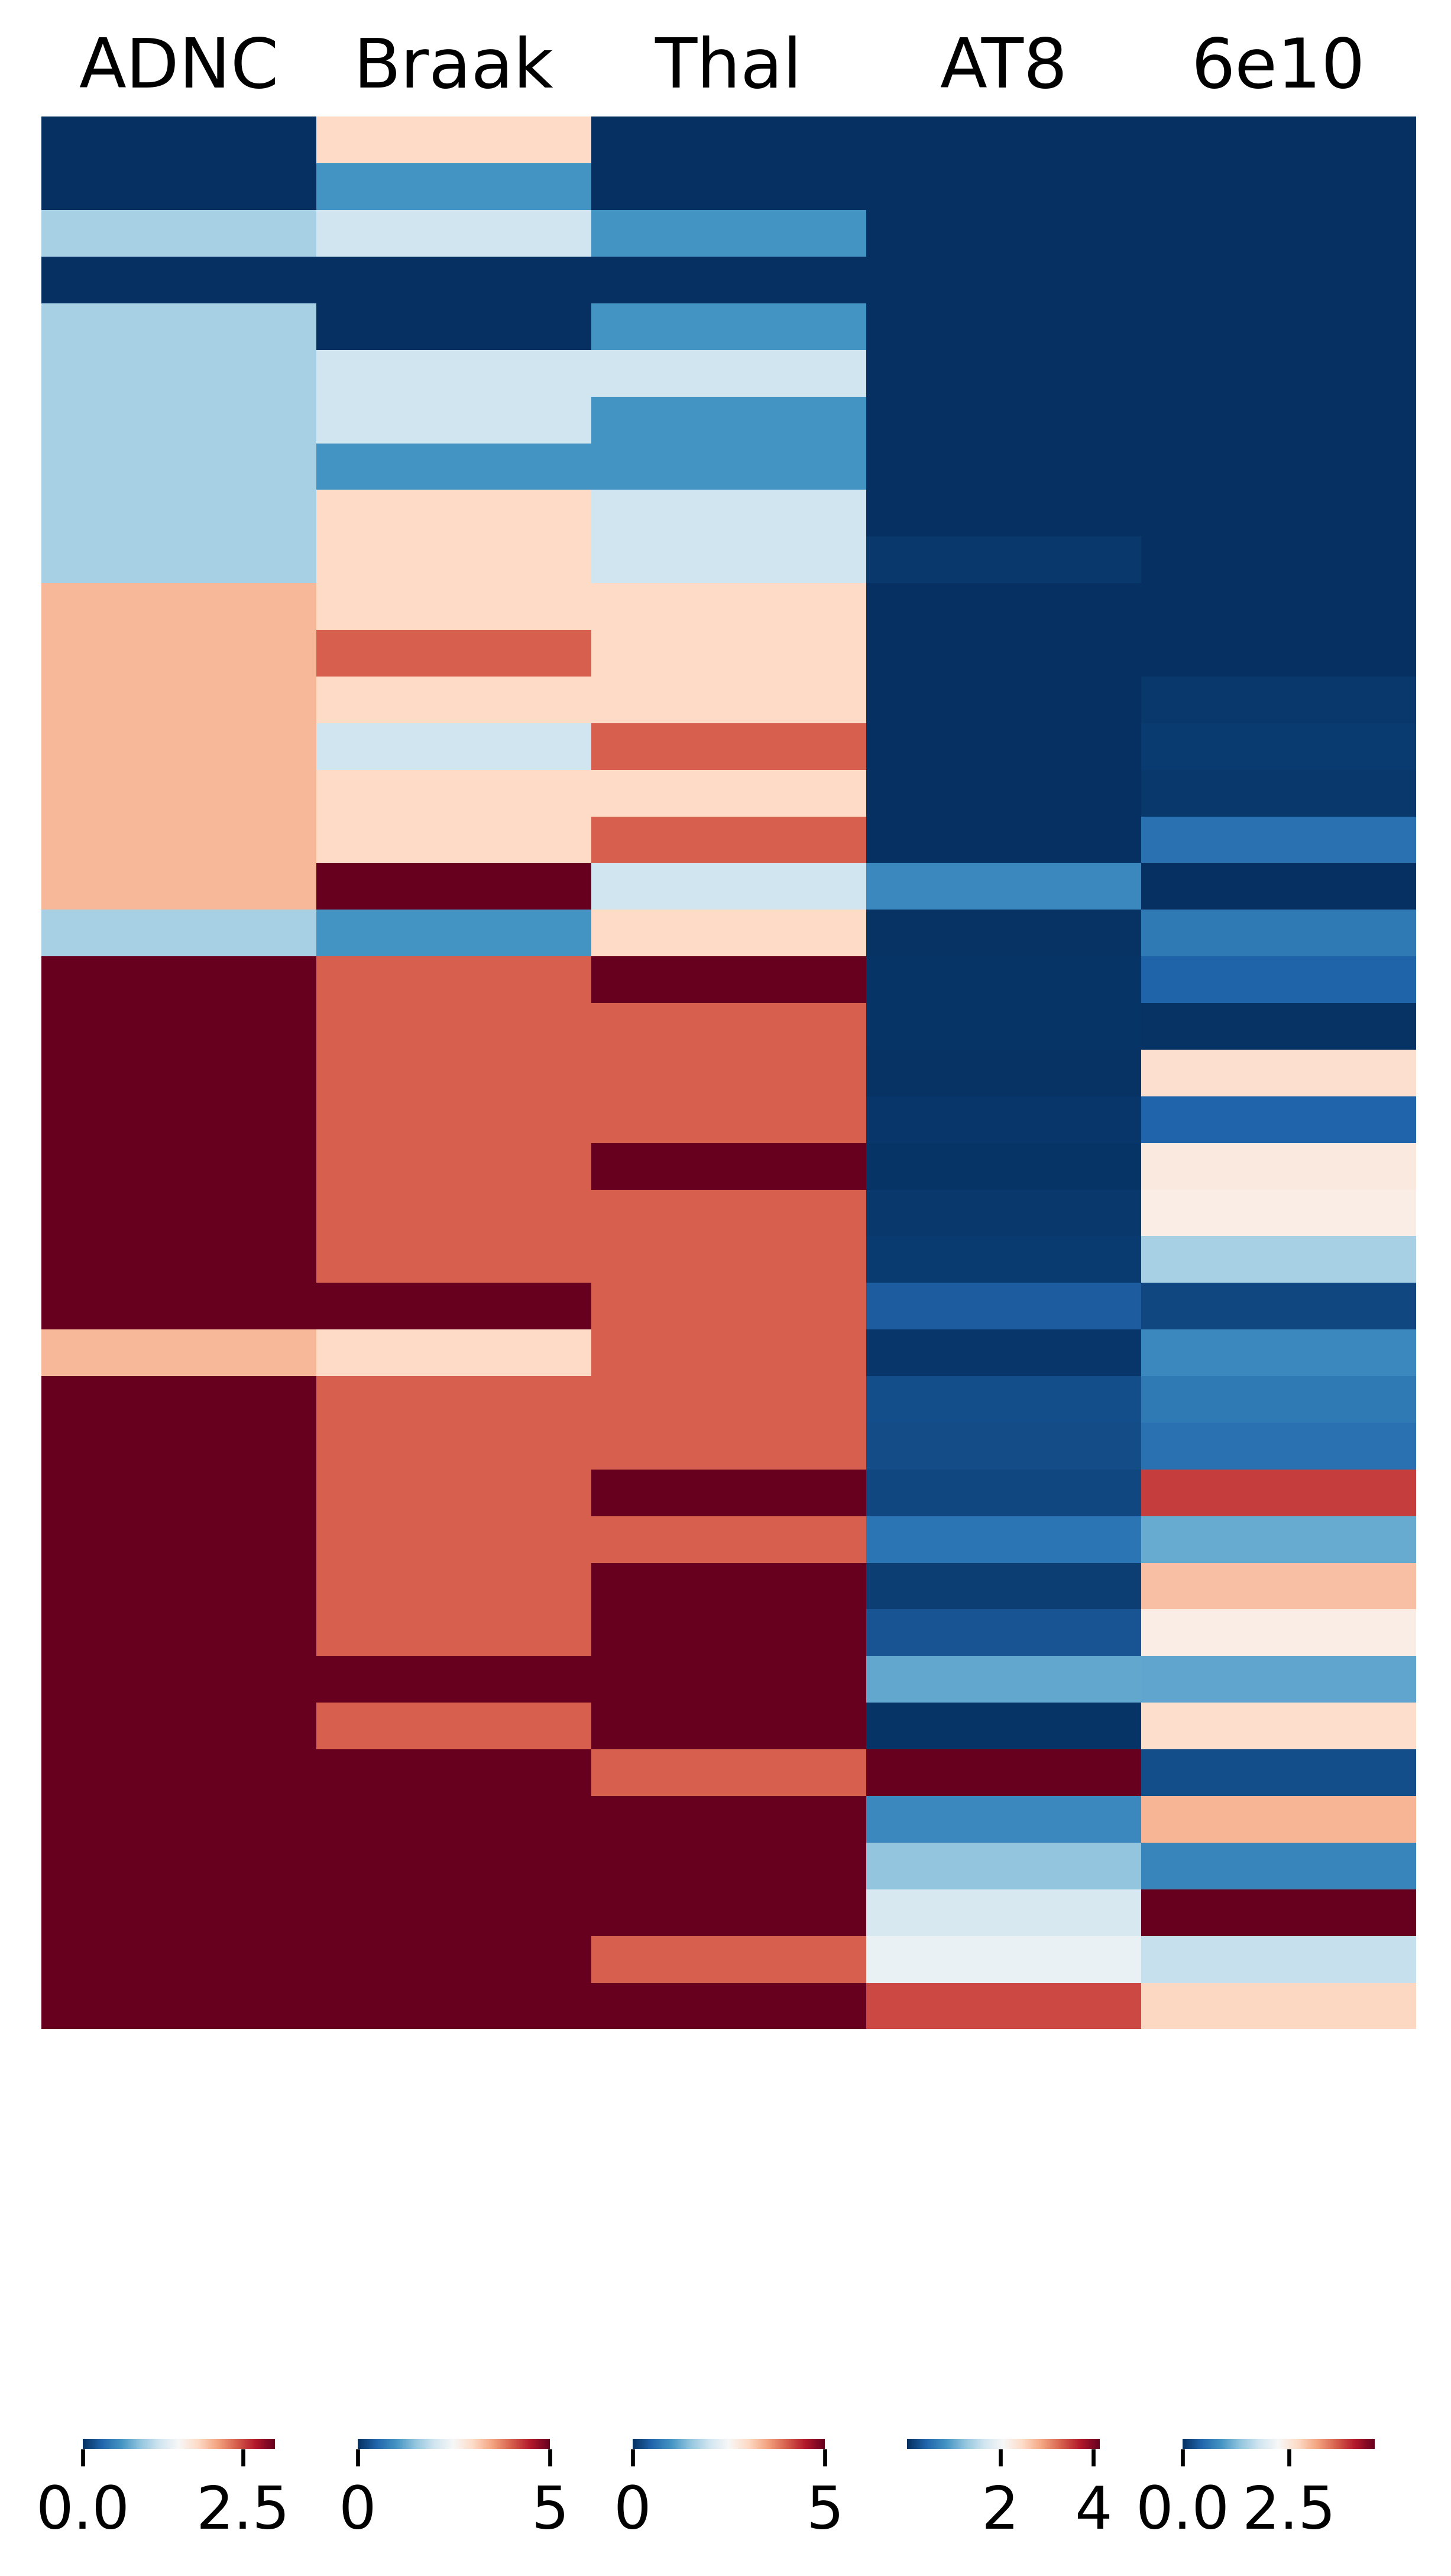

In [27]:
fig, axes = plt.subplots( 1,len(data.columns),  figsize=(5,  10), sharex=True)

for i, col in enumerate(data.columns):
    
    sns.heatmap(data = pd.DataFrame(data[col].cat.codes) if hasattr(data[col], 'cat') else data[[col]], ax=axes[i], cmap='RdBu_r', cbar=True,
                yticklabels=False, xticklabels = False,  cbar_kws={"shrink": 0.7, "orientation": "horizontal"}, ) # Show y-labels only for the first subplot

    axes[i].set_ylabel('') # Remove default y-axis label
        
    axes[i].set_title(col, fontsize = 14)
    cbar = axes[i].collections[0].colorbar
    cbar.ax.tick_params(labelsize=12)
    plt.subplots_adjust(wspace=0, hspace=0)